# Post-class session 1 — single-leader replication

Building a single-leader network and showing that network latency still causes
out-of-order delivery, even though every write goes through one node.

In [20]:
from dslabs import Cluster
from dslabs.nodes import NodeMultiLeader, NodeSingleLeader

## Single-leader

`n1` is the leader. A write sent to a follower is forwarded to the leader,
which applies it and broadcasts it to the followers. With a single write there
is nothing to reorder, so everyone agrees.

In [21]:
cluster = Cluster(NodeSingleLeader, 3, leader_id="n1", seed=1)
cluster.put("n1", "x", 1)   # follower write -> forwarded to n1 -> broadcast
cluster.run_until(500)
cluster.values("x")

{'n1': 1, 'n2': 1, 'n3': 1}

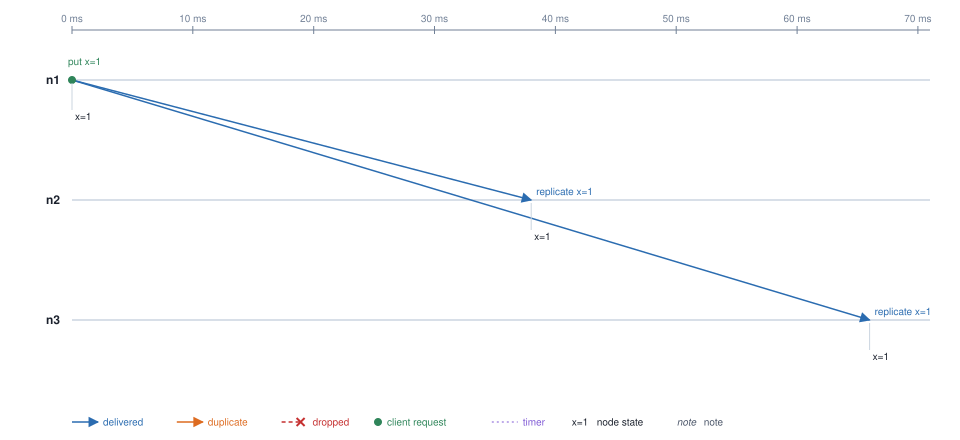

In [22]:
cluster.diagram()

## The problem: two writes, one key

Now the client writes `x = 1` and then `x = 2`, both at the leader, 5 ms apart.
The leader applies them in that order — that is the whole point of having a leader.
It then sends two independent replication messages to each follower, and each
message draws its own latency from `latency_ms`.

A wide latency range (10–300 ms) makes the reordering easy to see, but it is not
required — it only makes an inversion likelier per run.

In [23]:
cluster = Cluster(NodeSingleLeader, 3, leader_id="n1", seed=0, latency_ms=(10, 300))

cluster.put("n1", "x", 1)
cluster.run_until(5)        # 5 ms later, well inside the network delay
cluster.put("n1", "x", 2)

cluster.run_until_idle()
cluster.values("x")

{'n1': 2, 'n2': 1, 'n3': 1}

The leader has `x = 2`. Both followers have `x = 1`, and the network is idle —
there is nothing left in flight, so this is the **final** state. The followers are
permanently stale.

Why: look at the order each node actually applied the writes in.

In [24]:
for nid in cluster.node_ids:
    print(nid, cluster[nid].log)

n1 [('x', 1), ('x', 2)]
n2 [('x', 2), ('x', 1)]
n3 [('x', 2), ('x', 1)]


The leader's log is `[x=1, x=2]`. Both followers' logs are `[x=2, x=1]` — they
received the second write first, applied it, and then the *older* write arrived
and overwrote it. Last-writer-wins on arrival order means the stale value wins.

The message table shows the latencies that caused it:

In [25]:
cluster.messages()

#,sent,from,to,message,outcome
#1,0 ms,n1,n2,replicate x=1,delivered @ 207 ms (+207 ms)
#2,0 ms,n1,n3,replicate x=1,delivered @ 225 ms (+225 ms)
#3,5 ms,n1,n2,replicate x=2,delivered @ 35 ms (+30 ms)
#4,5 ms,n1,n3,replicate x=2,delivered @ 147 ms (+142 ms)


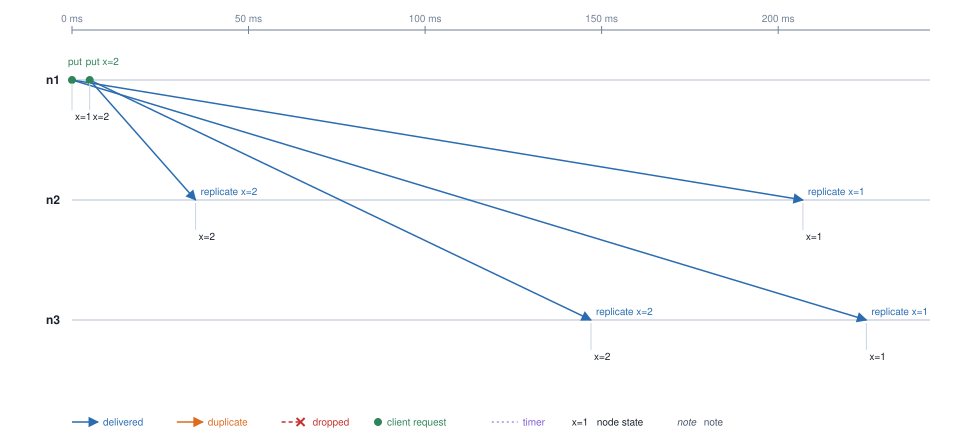

In [26]:
cluster.diagram()

The crossing arrows are the reordering: the `x=2` message overtakes `x=1` in flight.

In [27]:
cluster.explain("n2")

Messages to n2
 #  sent  from  to  message        outcome
#1  0 ms  n1    n2  replicate x=1  delivered @ 207 ms (+207 ms)
#3  5 ms  n1    n2  replicate x=2  delivered @ 35 ms (+30 ms)

Messages from n2
(no messages)

Timeline of n2
@      0 ms  n1 -> n2    send     #1 replicate x=1
@      5 ms  n1 -> n2    send     #3 replicate x=2
@     35 ms  n1 -> n2    deliver  #3 replicate x=2  (+30 ms)
@     35 ms  n2          state    x=2
@    207 ms  n1 -> n2    deliver  #1 replicate x=1  (+207 ms)
@    207 ms  n2          state    x=1

## Not a cherry-picked seed

Sweeping seeds shows how often this happens.

In [28]:
def diverges(seed):
    c = Cluster(NodeSingleLeader, 3, leader_id="n1", seed=seed, latency_ms=(10, 300))
    c.put("n1", "x", 1)
    c.run_until(5)
    c.put("n1", "x", 2)
    c.run_until_idle()
    return len(set(c.values("x").values())) > 1

bad = [s for s in range(100) if diverges(s)]
print(f"{len(bad)}/100 runs end with nodes disagreeing")

70/100 runs end with nodes disagreeing


## Why network latency still causes problems

A single leader gives the writes a **total order**: every write passes through
`n1`, so there is one unambiguous sequence, `x=1` then `x=2`. That fixes the
multi-leader problem of two nodes accepting conflicting writes at once.

But ordering the writes at the leader is not the same as *delivering* them in
that order. The leader sends one independent message per write per follower, and
each message is an independent event in the network with its own latency. Nothing
in the message says which write came first, and nothing in the follower checks.
A follower applies whatever arrives, in arrival order.

So when `x=2` (10 ms) overtakes `x=1` (300 ms), the follower applies `x=2`, then
applies `x=1` on top of it. The final value is the *older* write. And because
replication here is fire-and-forget — no retries, no acknowledgements, no
reconciliation — nothing ever corrects it. The cluster stays inconsistent forever.

The leader removed the ambiguity about what the order *is*. It did not give the
followers any way to *enforce* that order on arrival. To close the gap a follower
needs to be able to reject or reorder what arrives out of sequence, which means
the order has to travel with the messages — a per-key version or a monotonic
sequence number from the leader, with the follower ignoring anything older than
what it has already applied, and buffering or re-requesting anything that arrives
ahead of a gap.